## Replicate Figure 1
This notebook reproduces Figure 1 from the paper:
Bayesian Strategy Analysis.

It evaluates multiple strategies across trials and
plots their posterior probabilities.
>All configuration parameters are defined in config.py.
You do NOT need to modify this notebook.

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


In [5]:


# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]


alpha0, beta0 = set_priors(prior_type) 



In [6]:
# Collect strategy functions once
strategy_functions = {}

for strategy in strategies:
    try:
        strategy_functions[strategy] = getattr(strategymodels, strategy)
    except AttributeError:
        raise ValueError(f"Strategy '{strategy}' not found in strategymodels.")

In [7]:
# Initialise storage

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [8]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for strategy in strategies:

        strategy_fcn = strategy_functions[strategy]
        trial_type = strategy_fcn(rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_13986/831146610.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


## Figure 1d- Rule Strategies (MAP Probability)
This panel shows how the model’s belief in each rule-based strategy 
changes across trials.

Each line represents a different strategy:
- Go Left
- Go Right
- Go Cued

The y-axis shows the MAP probability (0–1), which represents 
how strongly the model believes that a strategy is being used.

If one strategy rises above 0.5 and stays high while others decrease,
this suggests that the animal has adopted that strategy.

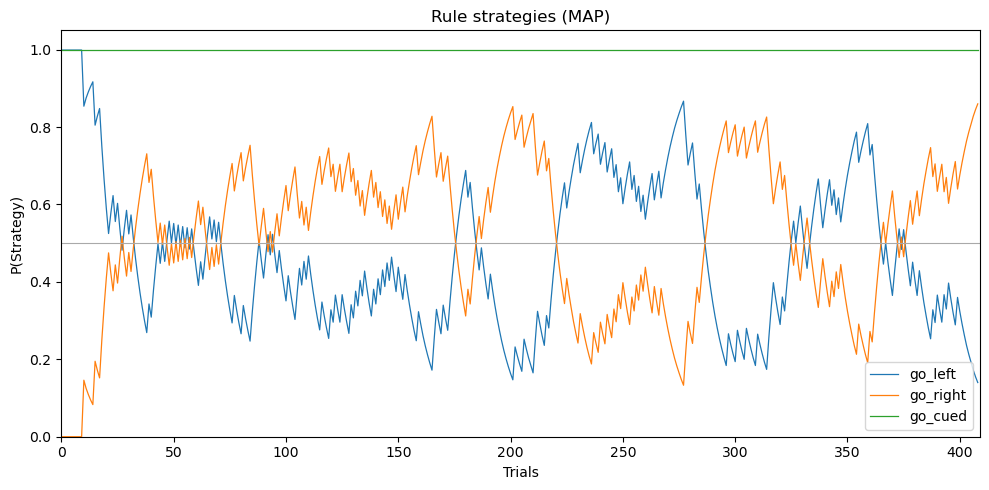

In [10]:
rule_strategies = ["go_left", "go_right", "go_cued"]

plt.figure(figsize=(10, 5))
for s in rule_strategies:
    plt.plot(Output_collection[s]["MAPprobability"], linewidth=0.9, label=s)

plt.axhline(0.5, color="darkgrey", linewidth=0.8)
plt.xlim(0, no_Trials)
plt.ylim(0, 1.05)
plt.xlabel("Trials")
plt.ylabel("P(Strategy)")
plt.title("Rule strategies (MAP)")
try:
    plotSessionStructure(TestData)
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# -------- Dynamic Observation --------

final_MAPs = {s: Output_collection[s]["MAPprobability"].iloc[-1]
              for s in rule_strategies}

dominant_rule = max(final_MAPs, key=final_MAPs.get)

print("\n--- Automatic Session Summary ---")
print("Final MAP values:", final_MAPs)
print("Dominant rule strategy:", dominant_rule)

# First crossing above chance
chance = 0.5
MAP_dom = Output_collection[dominant_rule]["MAPprobability"].values
crossings = np.where(MAP_dom > chance)[0]

if len(crossings) > 0:
    first_cross = crossings[0]
    print(f"{dominant_rule} first exceeded chance at trial {first_cross}.")
else:
    print("No rule strategy exceeded chance level.")


--- Automatic Session Summary ---
Final MAP values: {'go_left': np.float64(0.14), 'go_right': np.float64(0.86), 'go_cued': np.float64(0.999)}
Dominant rule strategy: go_cued
go_cued first exceeded chance at trial 0.


## Figure 1e – Posterior Precision

This panel shows the precision of the posterior distribution 
for selected strategies.

Precision reflects how confident the model is about its belief.

- Low precision → high uncertainty
- High precision → strong confidence

If precision increases while MAP probability stabilises,
this suggests that learning has become robust.

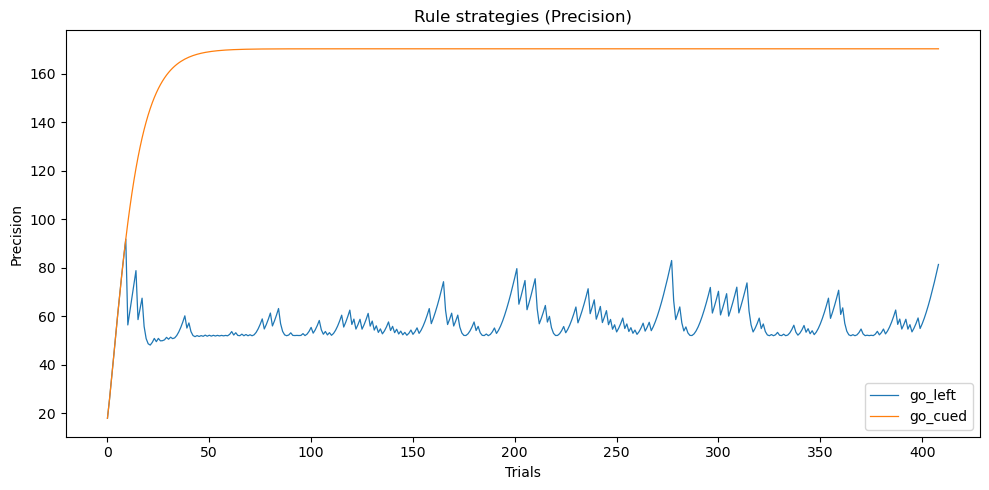

In [11]:
plt.figure(figsize=(10, 5))
for s in ["go_left", "go_cued"]:
    plt.plot(Output_collection[s]["Precision"], linewidth=0.9, label=s)

plt.xlabel("Trials")
plt.ylabel("Precision")
plt.title("Rule strategies (Precision)")
try:
    plotSessionStructure(TestData)
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()

### Observation – Precision

Precision increases as the dominant strategy stabilises.

This indicates that the model becomes more confident
about which strategy is being used.

The increase in precision supports the interpretation
that learning is robust rather than random fluctuation.

## Figure 1f – Exploratory Strategies

This panel shows exploratory strategies such as:
- Win-Stay
- Lose-Shift (Spatial or Cued)

These strategies reflect trial-and-error behaviour.

If exploratory strategies are high early in the session
and later decrease while a rule-based strategy increases,
this suggests that the animal has discovered the correct rule.

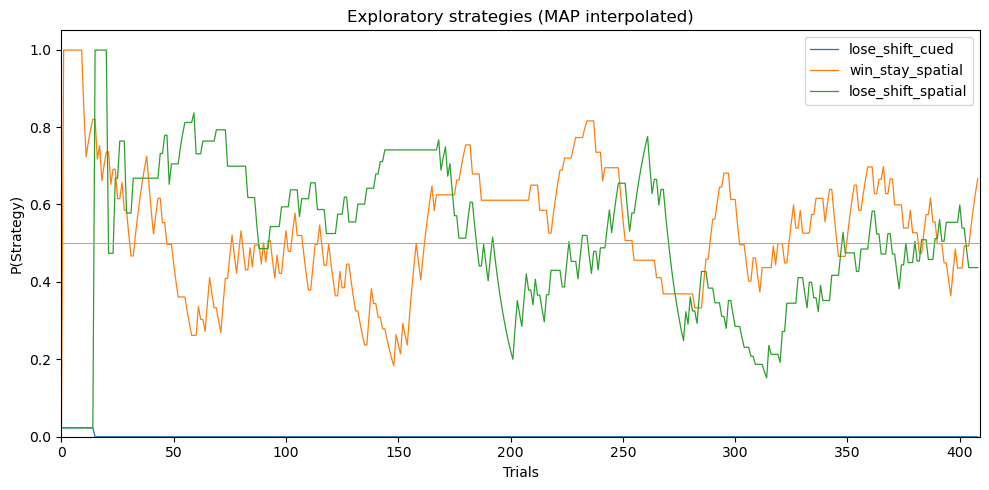

In [13]:
explore_strategies = ["lose_shift_cued", "win_stay_spatial", "lose_shift_spatial"]

plt.figure(figsize=(10, 5))
for s in explore_strategies:
    plt.plot(Output_collection[s]["MAPprobability_interpolated"], linewidth=0.9, label=s)

plt.axhline(0.5, color="darkgrey", linewidth=0.8)
plt.xlim(0, no_Trials)
plt.ylim(0, 1.05)
plt.xlabel("Trials")
plt.ylabel("P(Strategy)")
plt.title("Exploratory strategies (MAP interpolated)")
try:
    plotSessionStructure(TestData)
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()

### Observation – Exploratory Behaviour

Exploratory strategies tend to be higher early in the session
and decrease once a rule-based strategy becomes dominant.

This suggests that the animal initially explores
different behavioural options before committing to a stable rule.